In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv("../data/spotify.csv")

## Data Cleaning

- Removed the unnecessary `Unnamed: 0` column, which represented a saved DataFrame index and did not provide analytical value.
- Removed 1 record containing missing metadata in the `artists`, `album_name`, and `track_name` fields.
- Verified and confirmed that all remaining columns had appropriate data types for analysis.
- Dataset size after initial cleaning: **113,999 tracks**.

## Duplicate Record Handling

Initial inspection revealed approximately **24,000 duplicate track records** based on the Spotify `track_id`.

Further analysis showed that several tracks appeared multiple times within the dataset. To prevent duplicate observations from biasing popularity metrics, genre statistics, and audio feature analysis, duplicate records were removed using `track_id` as the unique identifier.


This ensured that each Spotify track was represented only once in the final dataset used for analysis.

In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [10]:
df['track_id'].duplicated().sum()

np.int64(24259)

In [11]:
df.dropna(inplace=True)
df.drop(columns='Unnamed: 0',inplace=True)
df = df.drop_duplicates(subset='track_id')

In [12]:
df['track_id'].duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Exploratory Analysis

In [14]:
df.shape

(89740, 20)

In [15]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89740.000000,8.974000e+04,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000
mean,33.198808,2.291444e+05,0.562166,0.634458,5.283530,-8.498994,0.636973,0.087442,0.328285,0.173415,0.216971,0.469474,122.058134,3.897426
std,20.580640,1.129458e+05,0.176692,0.256606,3.559912,5.221518,0.480875,0.113278,0.338321,0.323849,0.194885,0.262864,30.117651,0.453437
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322250,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.262750,4.000000
50%,33.000000,2.132955e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097625,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Dataset Overview

The cleaned dataset contains approximately 90,000 unique Spotify tracks and 20 features describing track popularity, audio characteristics, and genre information.

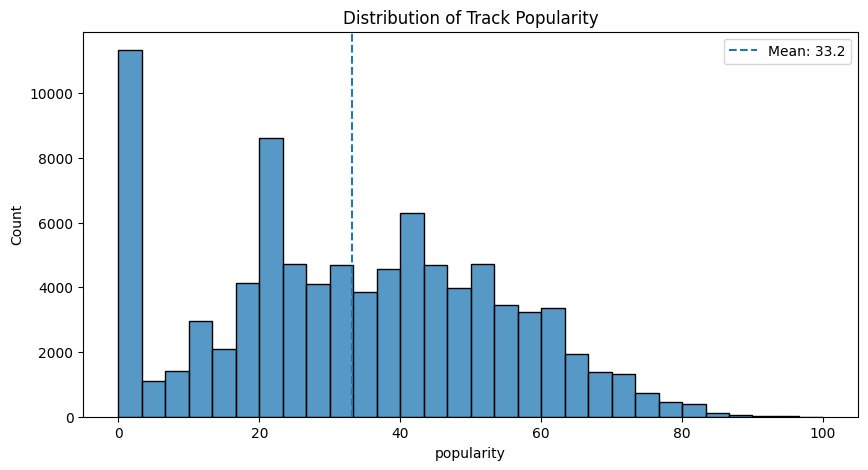

In [16]:
mean_popularity = df['popularity'].mean()

plt.figure(figsize=(10,5))
sns.histplot(df['popularity'], bins=30)

plt.axvline(
    mean_popularity,
    linestyle='--',
    label=f'Mean: {mean_popularity:.1f}'
)

plt.legend()
plt.title('Distribution of Track Popularity')
plt.show()

- A substantial proportion of tracks have a popularity score of 0, indicating that many songs in the dataset receive little to no recent engagement on Spotify.

In [17]:
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
genre_popularity

track_genre
k-pop       59.423581
pop-film    59.096933
metal       56.422414
chill       53.738683
latino      51.788945
sad         51.109929
grunge      50.587007
indian      49.765348
anime       48.776884
emo         48.500000
Name: popularity, dtype: float64

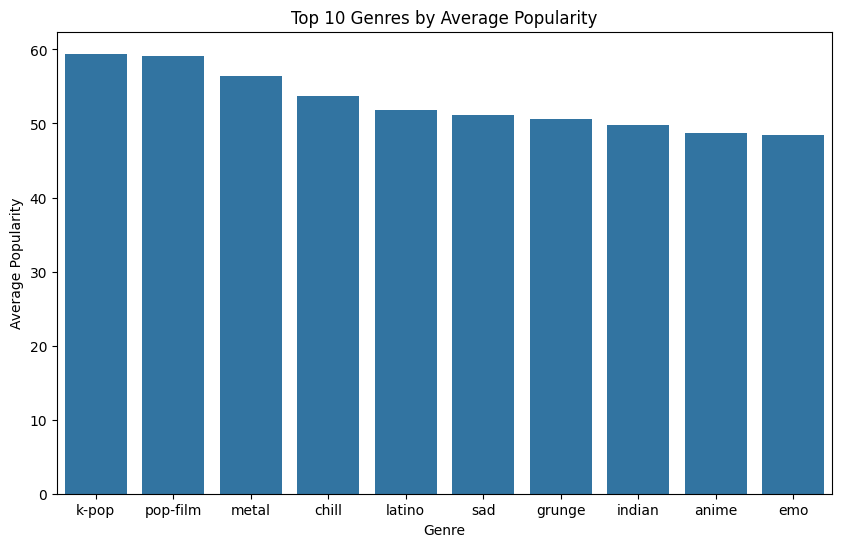

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(genre_popularity)
#genre_popularity.plot(kind='bar')
plt.title("Top 10 Genres by Average Popularity")
plt.ylabel('Average Popularity')
plt.xlabel('Genre')
plt.show()

- Most Popular Genre `K-pop` has the highest average popularity
- Distribution among top 10 genres spans a narrow range from 59.9(k-pop) to 48.5(emo) also emphasizing diversity because no one genre significantly dominates popularity

In [19]:
genre_unpopularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).tail(10)
genre_unpopularity

track_genre
idm               15.522222
kids              14.770791
grindcore         14.521827
classical         13.362168
chicago-house     12.333667
detroit-techno    11.130753
latin              9.855072
jazz               9.790076
romance            3.549779
iranian            2.224696
Name: popularity, dtype: float64

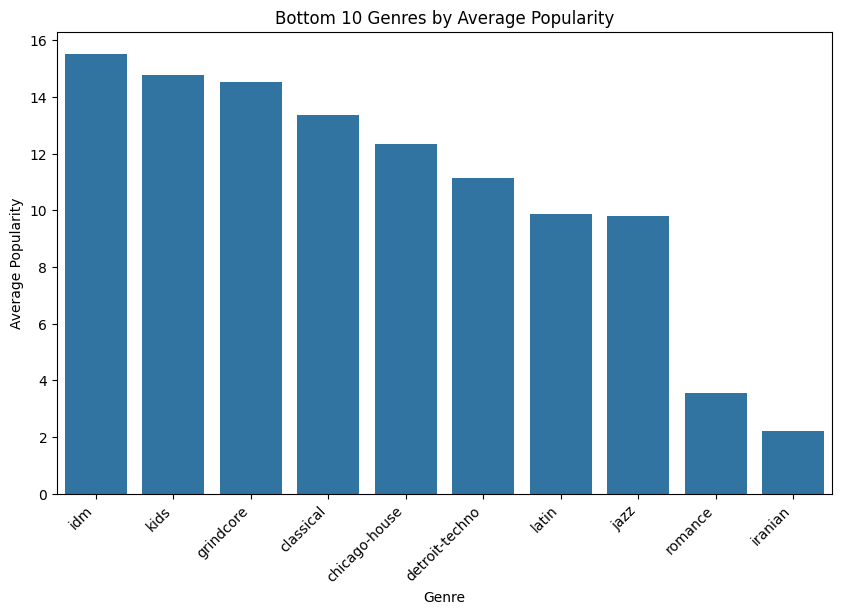

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(genre_unpopularity)

plt.title("Bottom 10 Genres by Average Popularity")
plt.xticks(rotation=45, ha='right') 
plt.ylabel('Average Popularity')
plt.xlabel('Genre')
plt.show()

- Niche vs. Mainstream Context: The genres listed are highly specific or traditionally niche (e.g., grindcore, idm, detroit-techno). Even genres like classical and jazz, which have massive historical significance, score low on modern average popularity metrics, likely due to a high volume of tracks that receive low streaming traffic compared to mainstream pop or rap.
- ​The Least Popular Genre: `Iranian` music has the lowest average popularity
- romance and iranian are significantly less popular than the other eight genres on this list. romance drops heavily to under 4, and iranian drops even further.




### Correlation Analysis

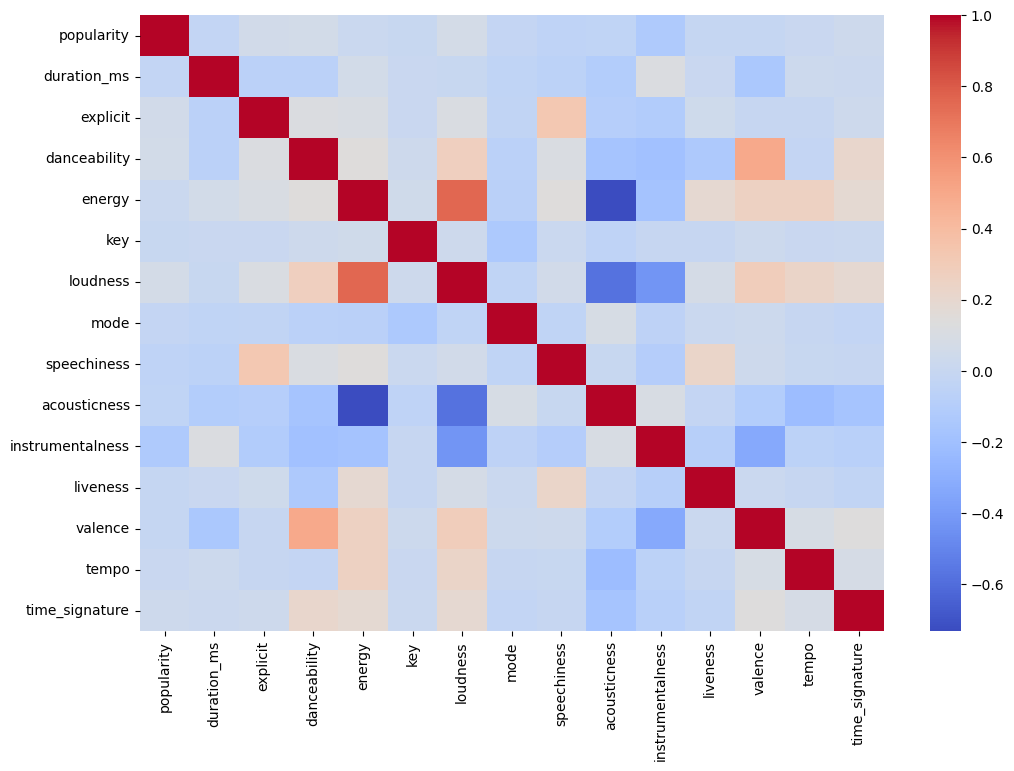

In [21]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [22]:
corr['popularity'].sort_values(ascending=False)

popularity          1.000000
loudness            0.071674
danceability        0.064275
explicit            0.054898
time_signature      0.036898
energy              0.013725
tempo               0.007280
key                 0.003441
valence            -0.011508
liveness           -0.013857
mode               -0.016238
duration_ms        -0.023157
acousticness       -0.038828
speechiness        -0.047086
instrumentalness   -0.127477
Name: popularity, dtype: float64

### Insights ###
- Tracks with higher instrumentalness tend to have lower popularity scores. This suggests that songs containing vocals generally achieve greater popularity on Spotify than predominantly instrumental tracks.
- Louder tracks tend to be slightly more popular, although the relationship is weak.
- Explicit tracks exhibit a slightly higher popularity score on average, although the effect is small.

- The correlation analysis revealed that no individual audio feature exhibited a strong relationship with popularity. This suggests that track popularity is likely influenced by factors beyond the musical attributes available in the dataset, such as artist recognition, marketing, playlist exposure, and listener trends. 

### Explicit vs Non-Explicit

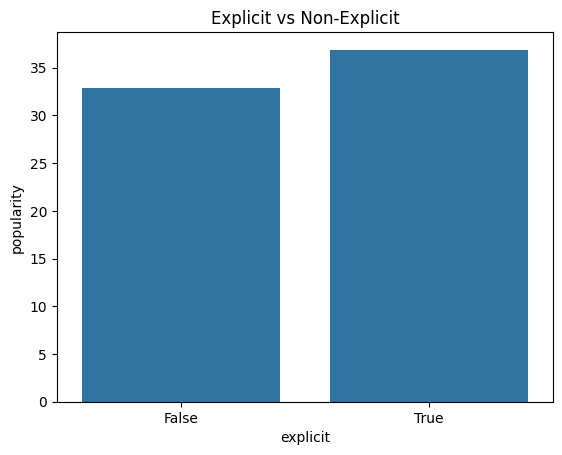

In [23]:
plt.Figure(figsize=(10,6))
sns.barplot(df.groupby('explicit')['popularity'].mean())
plt.title('Explicit vs Non-Explicit')
plt.show()

- Explicit tracks have a higher average popularity score compared to non-explicit tracks
- While explicit tracks perform better, the gap isn't completely overwhelming . This suggests that while having explicit content might give a track a slight edge potentially due to the popularity of genres like modern hip-hop, rap, or streaming-friendly pop, clean tracks still maintain a very competitive baseline level of popularity overall.





### Genre Characteristics
Which genres are the most energetic, happiest, or danceable?

In [24]:
genre_features = (
    df.groupby('track_genre')
      [['danceability','energy','valence']]
      .mean()
)
dance = genre_features.sort_values(by='danceability', ascending=False)['danceability'].head()
energy = genre_features.sort_values(by='energy', ascending=False)['energy'].head()
val = genre_features.sort_values(by='valence', ascending=False)['valence'].head()

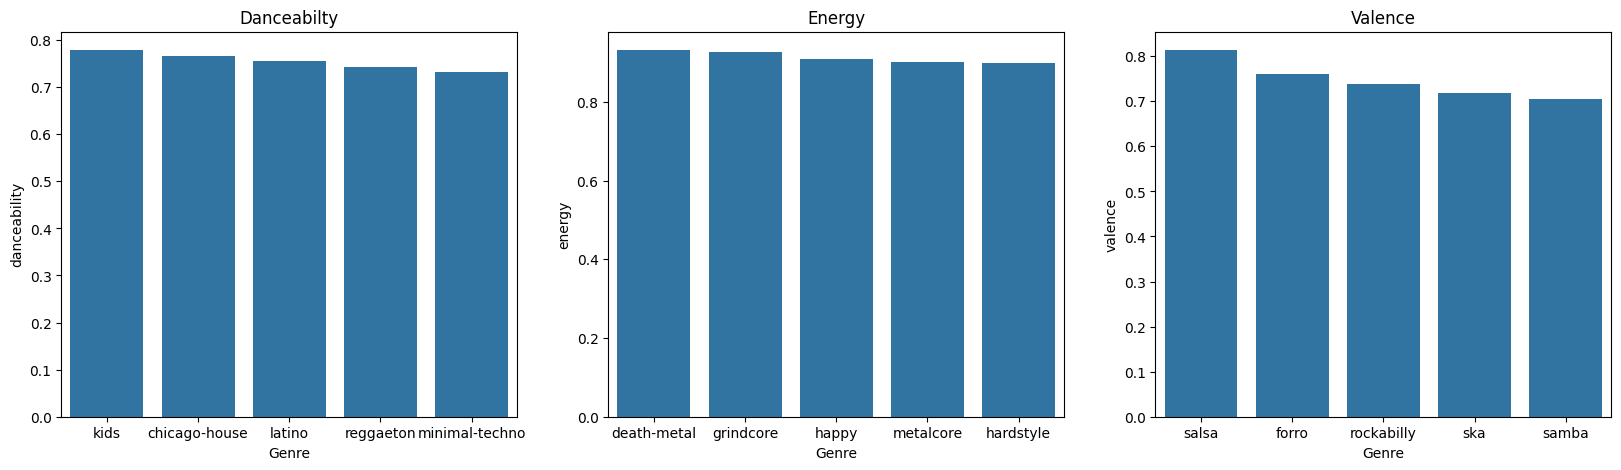

In [25]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.barplot(data=dance)
plt.xlabel('Genre')
plt.title('Danceabilty')

plt.subplot(1,3,2)
sns.barplot(data=energy)
plt.xlabel('Genre')
plt.title('Energy')

plt.subplot(1,3,3)
sns.barplot(val)
plt.xlabel('Genre')
plt.title('Valence')

plt.show()



### Danceability
- kids, chicago-house, latino, reggaeton, and minimal-techno lead the pack in danceability. All five feature highly uniform scores, tightly packed between roughly 0.73 and 0.78.
- Interestingly, kids music takes the top spot
### Energy
- As expected, aggressive and fast-paced genres dominate this metric. death-metal and grindcore lead the chart, followed by happy, metalcore, and hardstyle.
### Valence
- salsa stands out significantly as the most positive, joyful, or upbeat genre, scoring above 0.80 in valence.
- Unlike the danceability and energy subplots—where the top 5 genres have nearly identical heights—the valence chart shows a much more visible downward slope. It drops from salsa (0.81) down to samba (0.70), showing a clearer tier system among the happiest genres








### Top Ten Tracks

In [26]:
df.nlargest(
    10,
    'popularity'
)[['track_name','artists','track_genre','popularity']]


,track_name,artists,track_genre,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
20008,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
67356,La Bachata,Manuel Turizo,latin,98
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,latin,97
67359,Tití Me Preguntó,Bad Bunny,latin,97
20000,Under The Influence,Chris Brown,dance,96
67559,Efecto,Bad Bunny,latin,96
79000,I Ain't Worried,OneRepublic,piano,96
67500,Ojitos Lindos,Bad Bunny;Bomba Estéreo,latin,95


### Characteristics of Popular vs Unpopular Songs

In [27]:
popular = df[df['popularity'] >= df['popularity'].quantile(0.9)]
unpopular = df[df['popularity'] <= df['popularity'].quantile(0.1)]

Text(0.5, 1.0, 'unpopular')

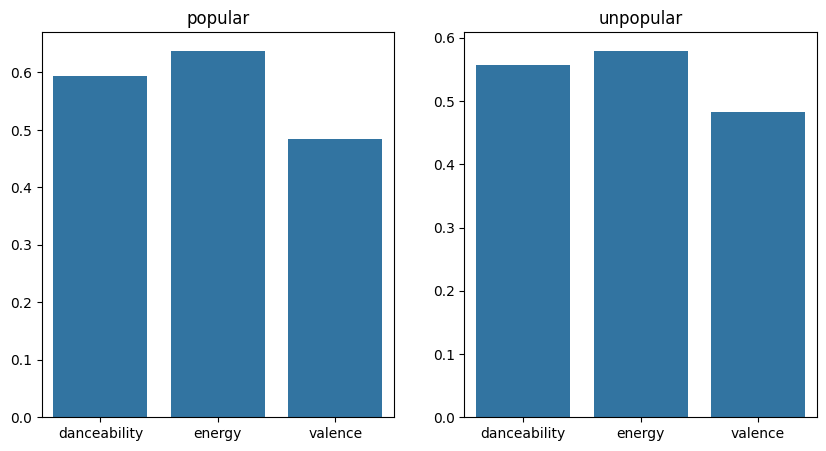

In [28]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(popular[['danceability','energy','valence']].mean())
plt.title('popular')

plt.subplot(1,2,2)
sns.barplot(unpopular[['danceability','energy','valence']].mean())
plt.title('unpopular')


- The overall sound profile for both popular and unpopular music looks almost exactly the same. In both charts, energy is the highest attribute, followed closely by danceability, with valence sitting as the lowest of the three.



## Key Findings
- The popularity distribution is highly uneven, with a substantial number of tracks receiving a popularity score of 0.
- Most tracks fall within the low-to-mid popularity range, while highly popular tracks are relatively rare.
- Correlation analysis revealed that no individual audio feature strongly predicts popularity.
- Instrumentalness showed the strongest relationship with popularity, exhibiting a weak negative correlation.
- Danceability, loudness, and explicit content showed weak positive relationships with popularity.
- Genre appears to have a greater influence on popularity patterns than individual audio features.

# Conclusion
 This project explored the relationship between Spotify track popularity and various audio characteristics using a dataset containing over 100,000 tracks.

 The audio features weren't strongly correlated with popularity.
 
Overall, the project demonstrates how exploratory data analysis can be used to uncover patterns within large datasets while also highlighting the limitations of drawing conclusions from audio features alone.